In [2]:
!pip install --upgrade scikit-learn

In [3]:
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

from sklearn.preprocessing import StandardScaler

In [4]:
df = pd.read_excel("/content/customer_data.xlsx")

In [5]:
df.head()

,customerID,Gender,Age,Annual Income,Spending Score
0,1,Male,19,150000,39
1,2,Male,21,180000,81
2,3,Female,20,200000,6
3,4,Female,23,250000,77
4,5,Female,31,100000,40


In [6]:
print(df.columns)

Index(['customerID', 'Gender', 'Age', 'Annual Income', 'Spending Score'], dtype='object')


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerID      8 non-null      int64 
 1   Gender          8 non-null      object
 2   Age             8 non-null      int64 
 3   Annual Income   8 non-null      int64 
 4   Spending Score  8 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 452.0+ bytes


In [8]:
df.isnull().sum()

,0
customerID,0
Gender,0
Age,0
Annual Income,0
Spending Score,0


In [9]:
df = df.dropna()

In [10]:
X = df[['Annual Income', 'Spending Score']]

In [11]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [12]:
wcss = []

for i in range(1,8):

    kmeans = KMeans(n_clusters=i, random_state=42)

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

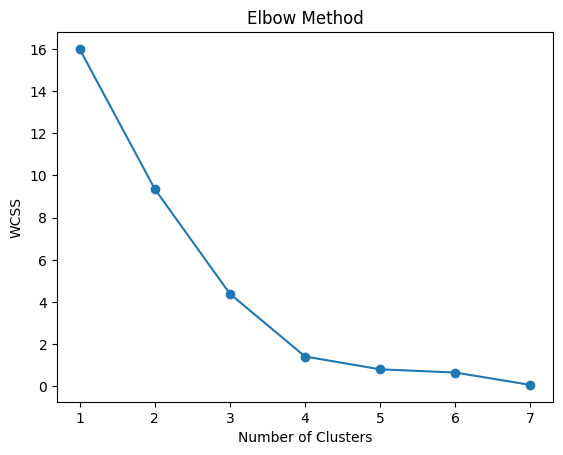

In [13]:
plt.plot(range(1,8), wcss, marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

In [14]:
kmeans = KMeans(n_clusters=5, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

In [15]:
df.head()

,customerID,Gender,Age,Annual Income,Spending Score,Cluster
0,1,Male,19,150000,39,3
1,2,Male,21,180000,81,2
2,3,Female,20,200000,6,0
3,4,Female,23,250000,77,2
4,5,Female,31,100000,40,3


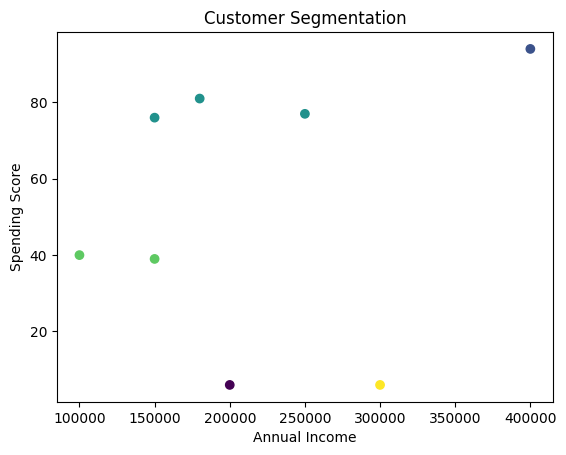

In [16]:
plt.scatter(
    df['Annual Income'],
    df['Spending Score'],
    c=df['Cluster']
)

plt.xlabel("Annual Income")

plt.ylabel("Spending Score")

plt.title("Customer Segmentation")

plt.show()

In [17]:
df['Cluster'].value_counts()

,count
Cluster,
2,3
3,2
0,1
4,1
1,1


In [18]:
df.to_csv("customer_segments.csv", index=False)

In [20]:
from google.colab import files

files.download("/content/customer_data.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>